In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 8),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime

import sys
sys.path.append("../../")

# CCP Basis (CME-LCH) Fair Value Model

Hybrid multi-factor regression + swap curve PCA enrichment.

**Factors:**
- Swap curve PCA scores (PC1=level, PC2=slope, PC3=curvature)
- SOFR-EFFR spread (dealer funding cost)
- BGCR-EFFR spread (repo-OIS collateral cost)
- BBB Corporate OAS (dealer credit proxy)
- Realized rate volatility
- Rate level
- Quarter-end / year-end dummies

In [48]:
from RVUtils.ccp_basis_fair_value import CCPBasisFairValueModel

In [63]:
model = CCPBasisFairValueModel(
    tenors=["2Y", "5Y", "10Y", "30Y"],
    start_date=datetime.date(2021, 4, 1),
    end_date=datetime.date(2026, 4, 8),
    n_pcs=3,
    realized_vol_window=60,
    ou_steps=63,
)

## 1. Fetch Raw Data

In [64]:
raw_df = model.fetch_data()
print(f"Raw data shape: {raw_df.shape}")
print(f"Date range: {raw_df.index.min()} to {raw_df.index.max()}")
print(f"\nColumns: {raw_df.columns.tolist()}")
raw_df.tail()

Raw data shape: (1834, 20)
Date range: 2021-04-01 00:00:00 to 2026-04-08 00:00:00

Columns: ['basis_2Y', 'basis_3Y', 'basis_5Y', 'basis_7Y', 'basis_10Y', 'basis_15Y', 'basis_20Y', 'basis_30Y', 'rate_2Y', 'rate_3Y', 'rate_5Y', 'rate_7Y', 'rate_10Y', 'rate_15Y', 'rate_20Y', 'rate_30Y', 'SOFR', 'EFFR', 'OBFR', 'BBB_OAS']


,basis_2Y,basis_3Y,basis_5Y,basis_7Y,basis_10Y,basis_15Y,basis_20Y,basis_30Y,rate_2Y,rate_3Y,rate_5Y,rate_7Y,rate_10Y,rate_15Y,rate_20Y,rate_30Y,SOFR,EFFR,OBFR,BBB_OAS
2026-04-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.64,NaN,NaN
2026-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.64,NaN,NaN
2026-04-06,0.954872,-52.411309,0.994570,37.498974,0.90,0.994570,0.985122,0.95,0.039770,0.036312,0.040817,0.041265,0.038929,0.040817,0.041607,0.041171,3.65,3.64,3.64,1.07
2026-04-07,0.956267,-55.502520,0.996665,39.309411,0.90,0.996665,0.987812,0.95,0.039814,0.036181,0.040909,0.041383,0.038929,0.040909,0.041758,0.041402,3.62,3.64,3.63,1.08
2026-04-08,0.906995,-57.612414,0.948469,40.511377,0.85,0.948469,0.939823,0.90,0.039419,0.035715,0.040546,0.041045,0.038511,0.040546,0.041460,0.041209,3.59,NaN,3.63,1.05


## 2. Build Factor Matrix

In [65]:
factors = model.build_factors()
print(f"Factor matrix shape: {factors.shape}")
print(f"\nFactors: {factors.columns.tolist()}")
factors.tail()

Factor matrix shape: (1834, 16)

Factors: ['PC1', 'PC2', 'PC3', 'sofr_ois_spread', 'repo_funding_spread', 'bbb_oas', 'realized_vol_2Y', 'realized_vol_5Y', 'realized_vol_10Y', 'realized_vol_30Y', 'rate_level_2Y', 'rate_level_5Y', 'rate_level_10Y', 'rate_level_30Y', 'qtr_end', 'yr_end']


,PC1,PC2,PC3,sofr_ois_spread,repo_funding_spread,bbb_oas,realized_vol_2Y,realized_vol_5Y,realized_vol_10Y,realized_vol_30Y,rate_level_2Y,rate_level_5Y,rate_level_10Y,rate_level_30Y,qtr_end,yr_end
2026-04-04,NaN,NaN,NaN,NaN,NaN,NaN,3.915207,3.733588,4.103793,3.381328,NaN,NaN,NaN,NaN,0.0,0.0
2026-04-05,NaN,NaN,NaN,NaN,NaN,NaN,3.977228,3.793194,4.167761,3.434562,NaN,NaN,NaN,NaN,0.0,0.0
2026-04-06,-0.000440,0.000288,0.000047,1.0,1.0,1.07,3.815085,3.644767,4.000888,3.317141,0.039770,0.040817,0.038929,0.041171,0.0,0.0
2026-04-07,-0.000145,-0.000278,-0.000106,-2.0,-1.0,1.08,3.809608,3.638726,3.998298,3.331531,0.039814,0.040909,0.038929,0.041402,0.0,0.0
2026-04-08,0.001067,-0.000146,-0.000082,NaN,-4.0,1.05,3.832903,3.654242,4.025685,3.300671,0.039419,0.040546,0.038511,0.041209,0.0,0.0


PCA Variance Explained:
  PC1: 93.8% (cumulative: 93.8%)
  PC2: 5.9% (cumulative: 99.7%)
  PC3: 0.2% (cumulative: 100.0%)
  PC4: 0.0% (cumulative: 100.0%)
  PC5: 0.0% (cumulative: 100.0%)
  PC6: 0.0% (cumulative: 100.0%)


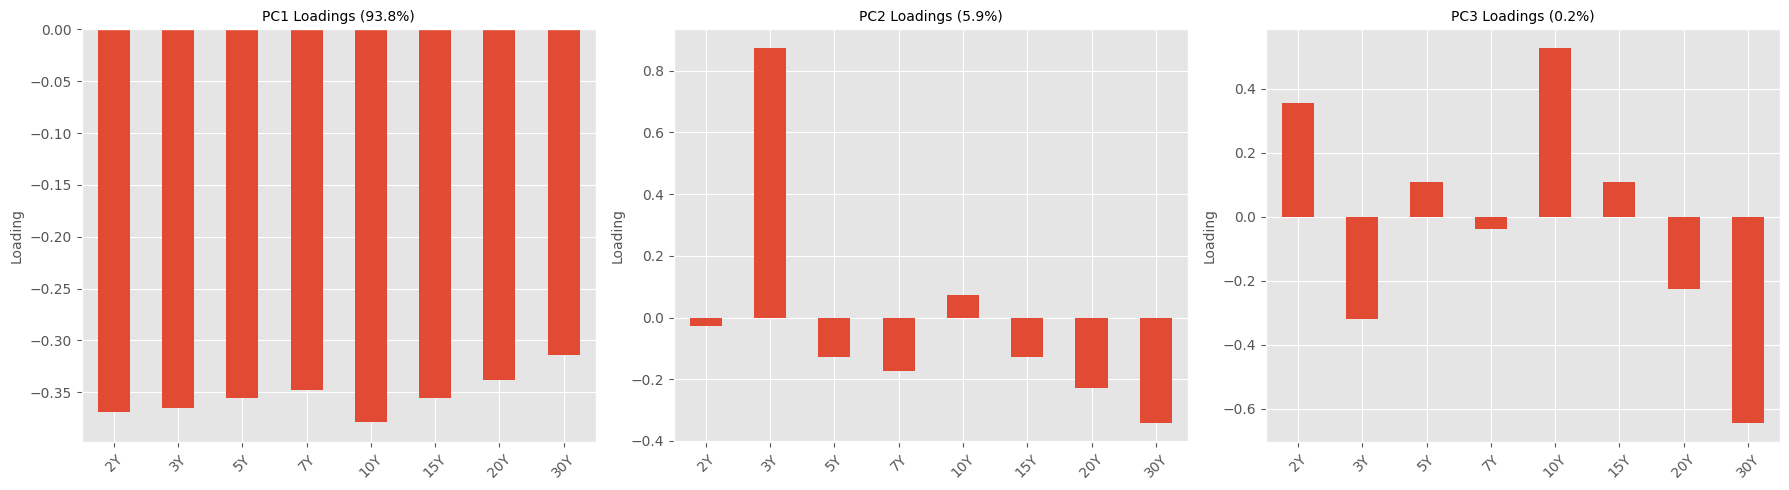

In [66]:
# PCA variance explained
if model._pca_model is not None:
    ev = model._pca_model.eigenvalues
    var_explained = ev / ev.sum() * 100
    cum_var = var_explained.cumsum()
    print("PCA Variance Explained:")
    for pc in var_explained.index[:6]:
        print(f"  {pc}: {var_explained[pc]:.1f}% (cumulative: {cum_var[pc]:.1f}%)")
    
    # Plot PCA loadings
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, ax in enumerate(axes):
        pc = f"PC{i+1}"
        model._pca_model.loadings[pc].plot(kind='bar', ax=ax, title=f"{pc} Loadings ({var_explained[pc]:.1f}%)")
        ax.set_ylabel('Loading')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Fit All Tenors

In [67]:
results = model.fit_all()
print(f"Successfully fitted: {list(results.keys())}")

Successfully fitted: ['2Y', '5Y', '10Y', '30Y']


In [68]:
# Cross-tenor summary
summary = model.summary()
display(summary)

,R2,adj_R2,n_obs,current_basis_bps,current_fv_bps,current_residual_bps,current_zscore,residual_mean,residual_std,ou_half_life_days
tenor,,,,,,,,,,
2Y,0.7015,0.6988,1107,0.9563,0.2080,0.7483,1.3048,0.0,0.5735,0.0
5Y,0.6779,0.6750,1107,0.9967,0.0507,0.9460,1.4916,0.0,0.6342,0.0
10Y,0.7129,0.7103,1107,0.9000,0.2837,0.6163,1.1537,-0.0,0.5342,0.0
30Y,0.6042,0.6006,1107,0.9500,-0.3818,1.3318,1.6121,0.0,0.8261,0.0


## 4. Fair Value Plots (per tenor)

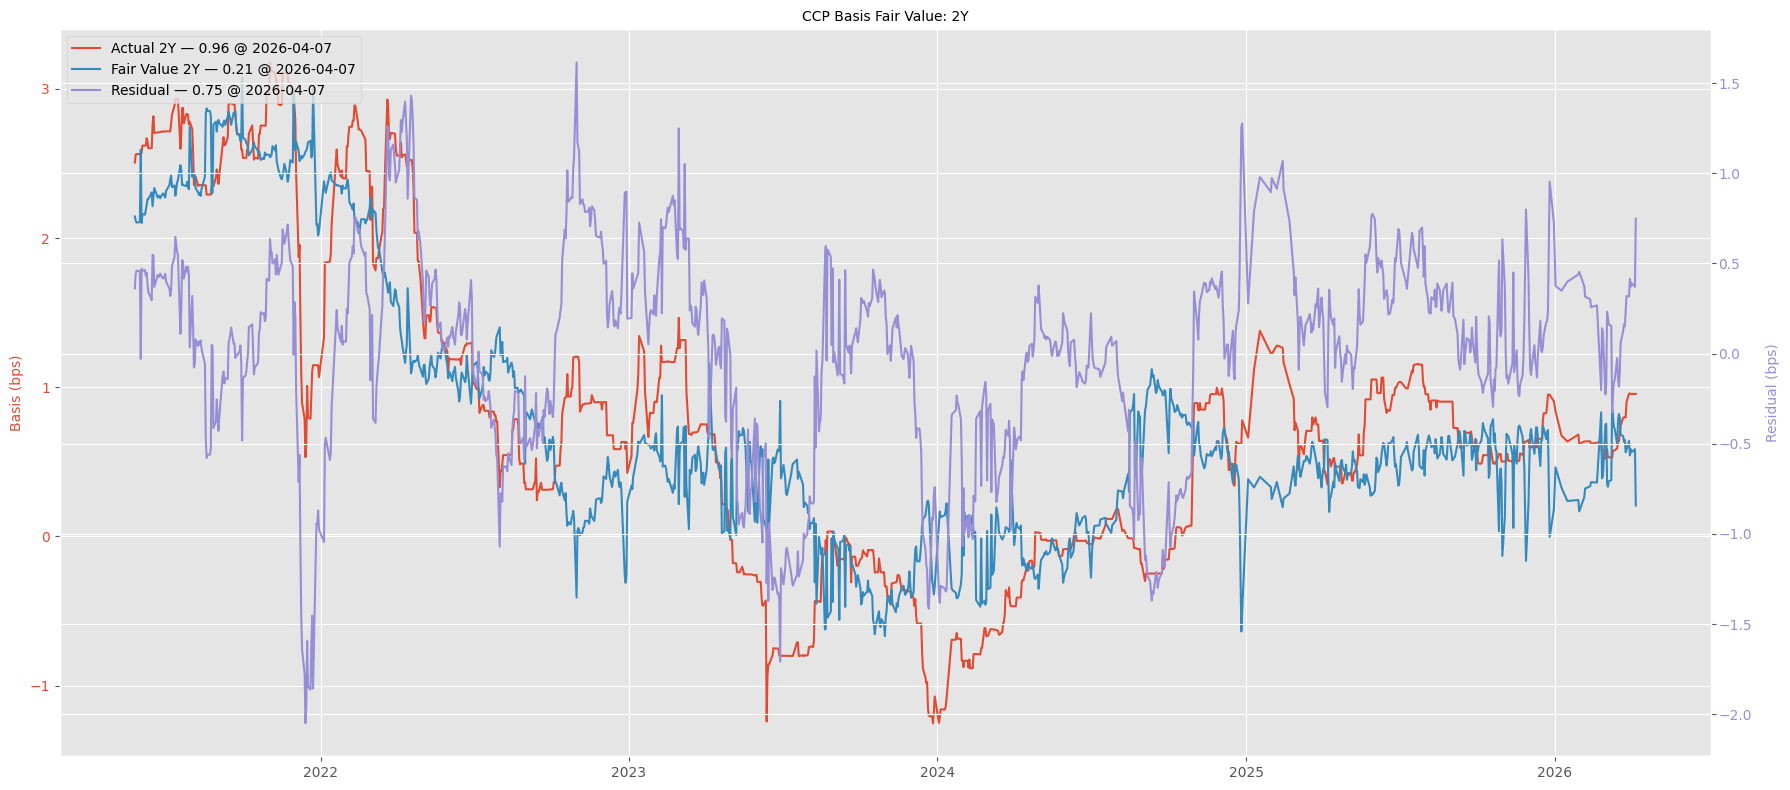

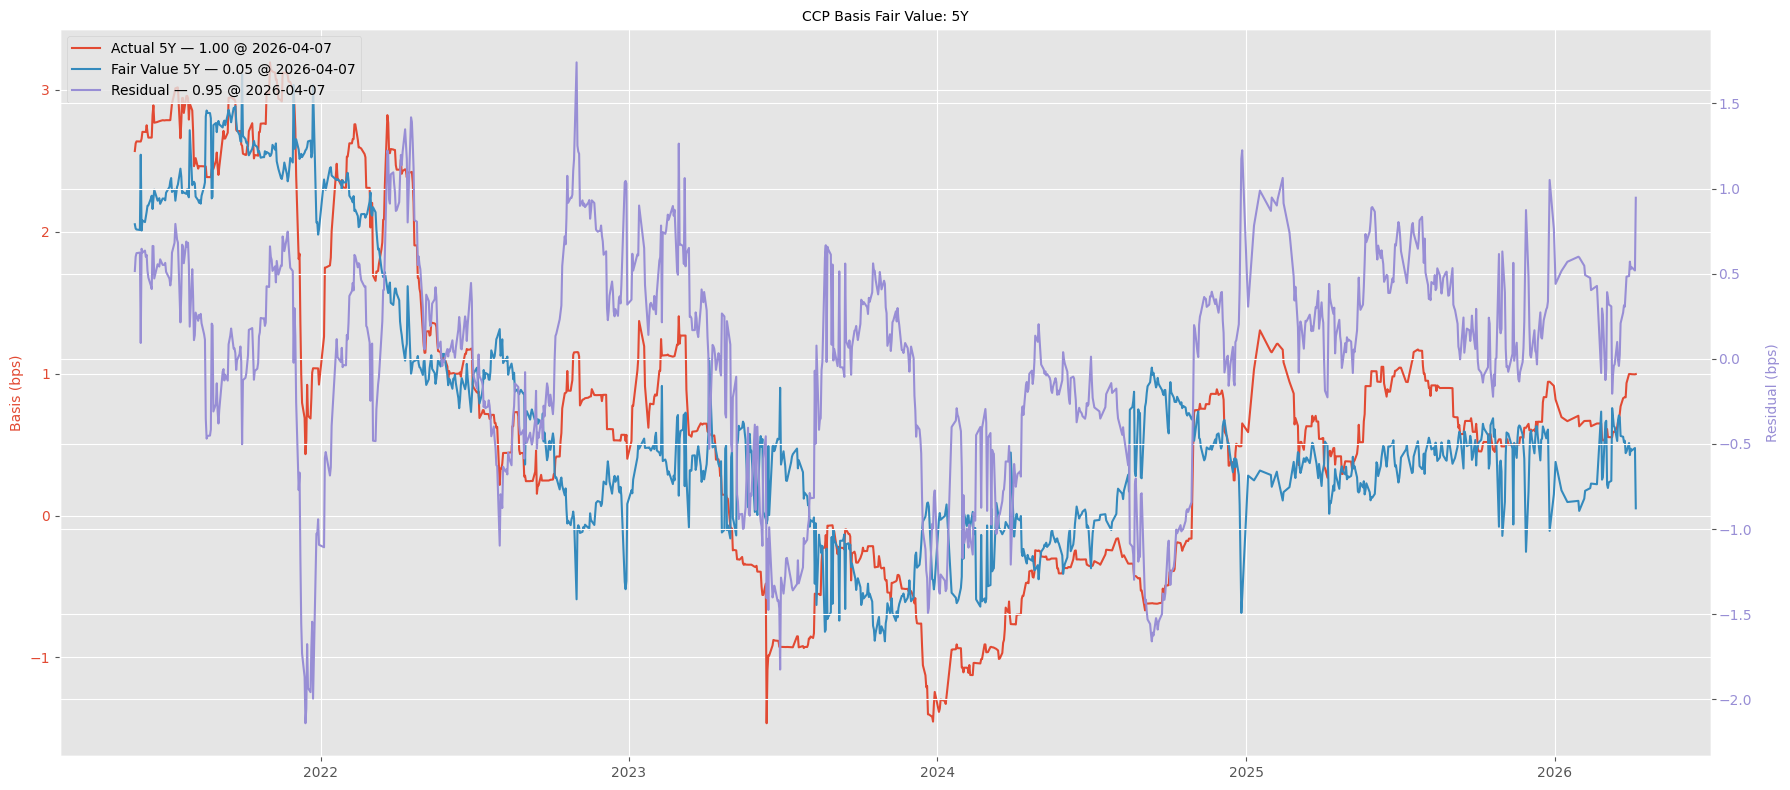

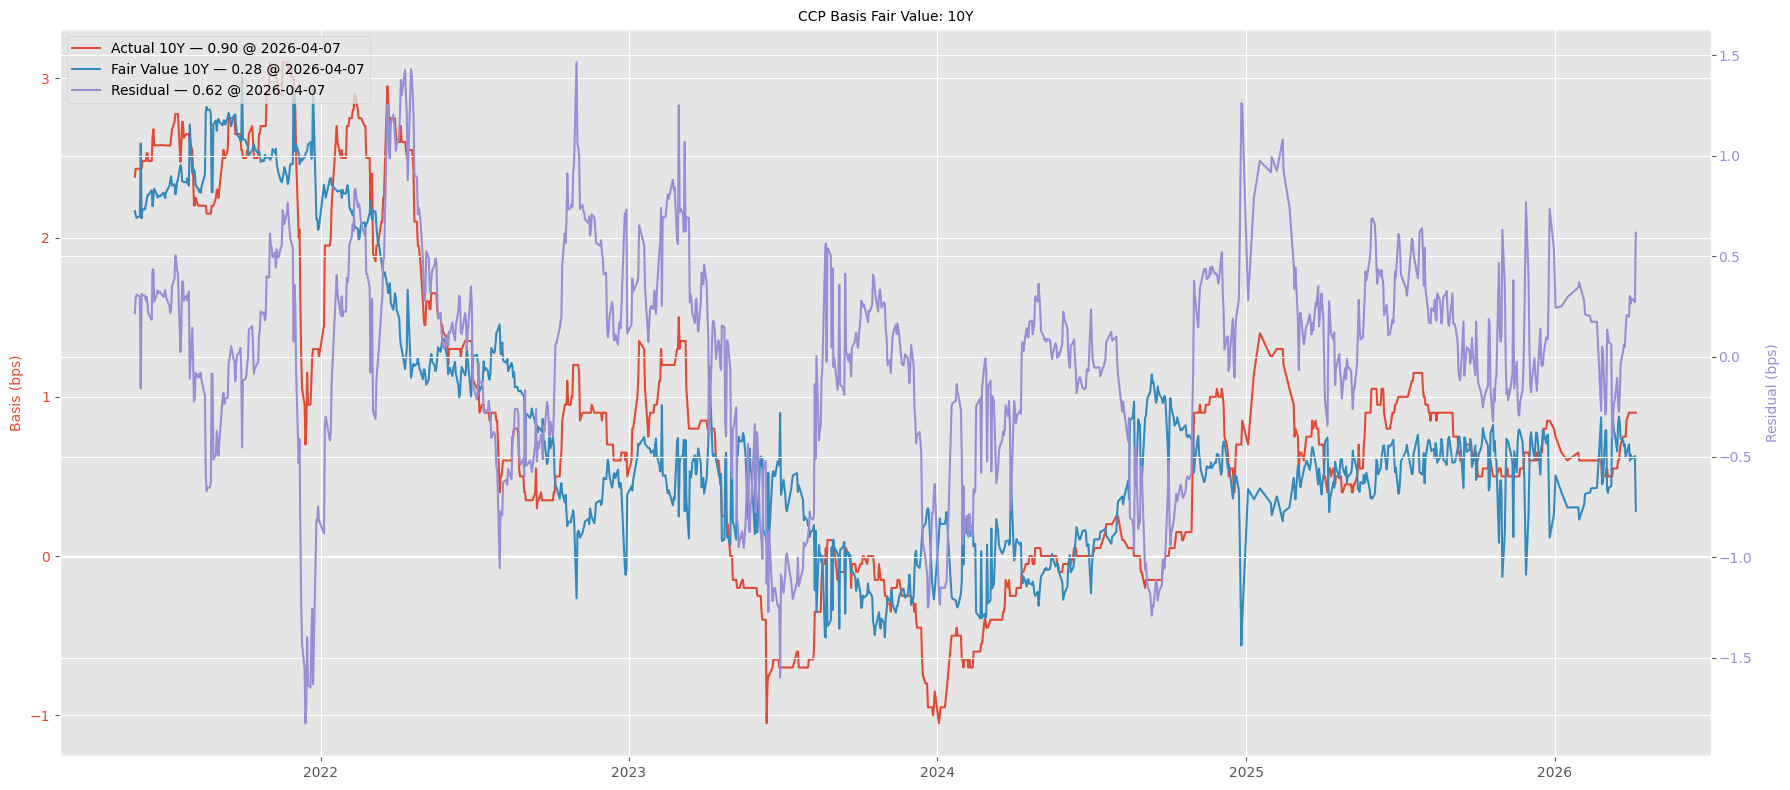

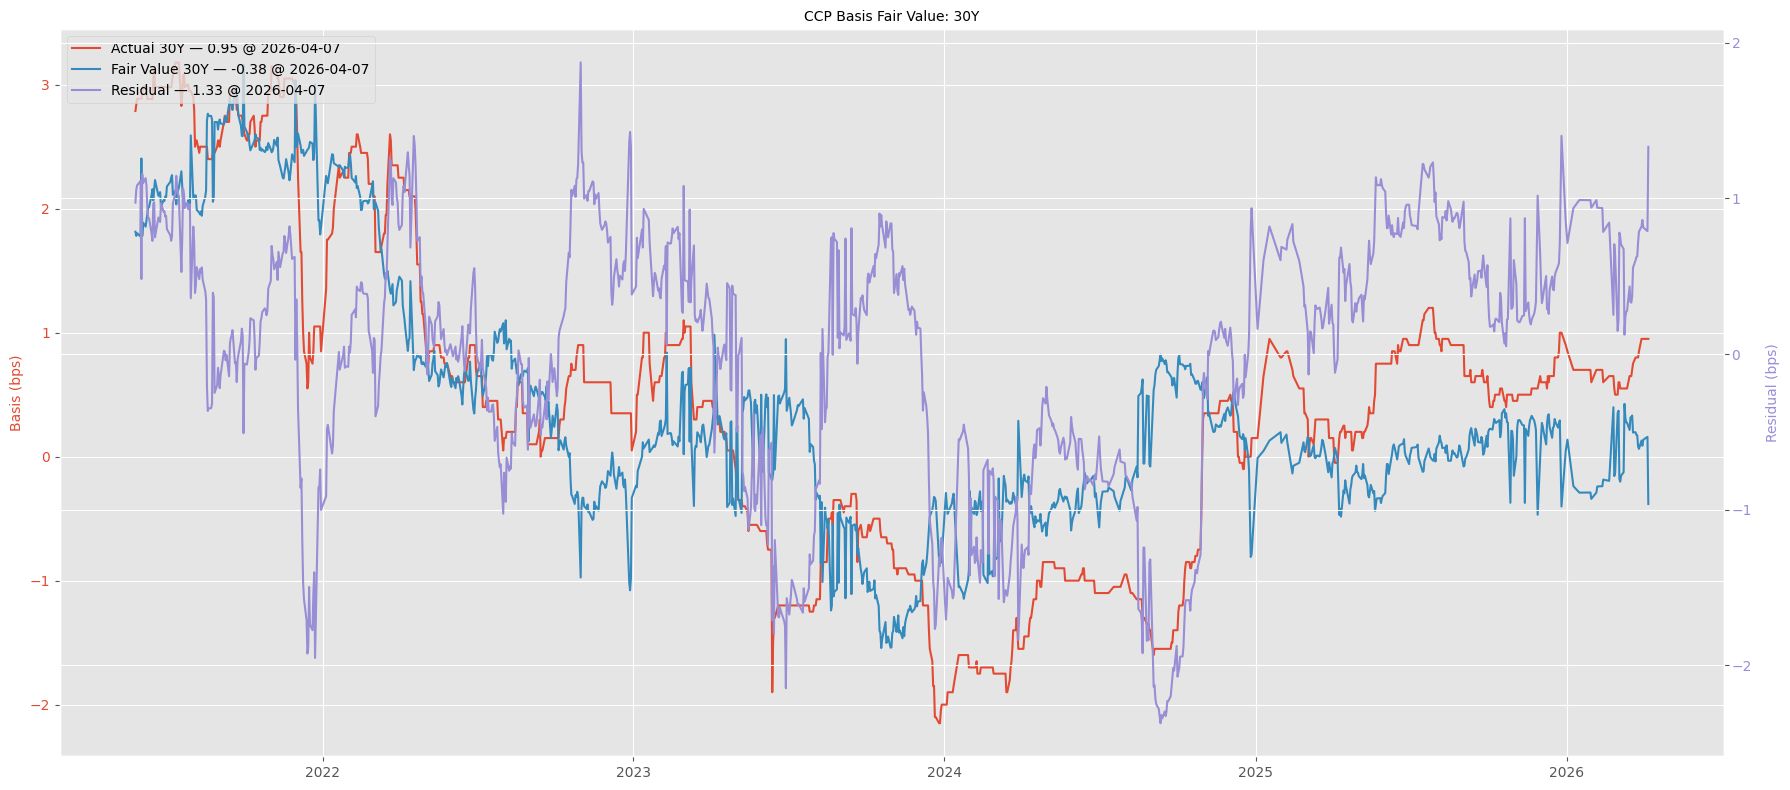

In [69]:
for tenor, result in results.items():
    model.plot_fair_value(result)
    plt.show()

## 5. Residual Z-Score Plots

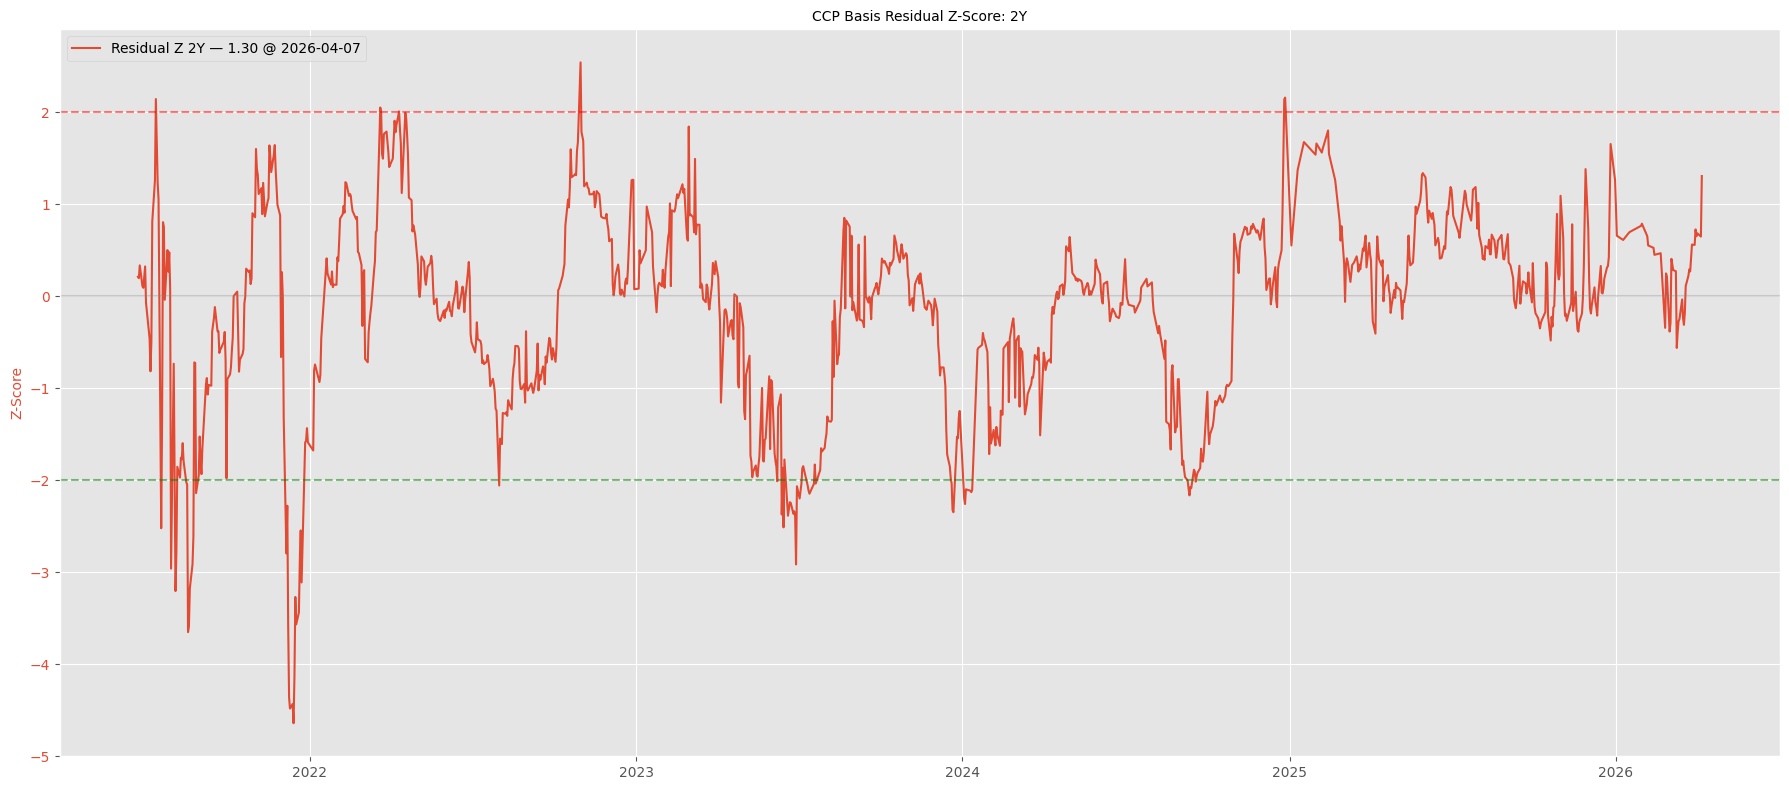

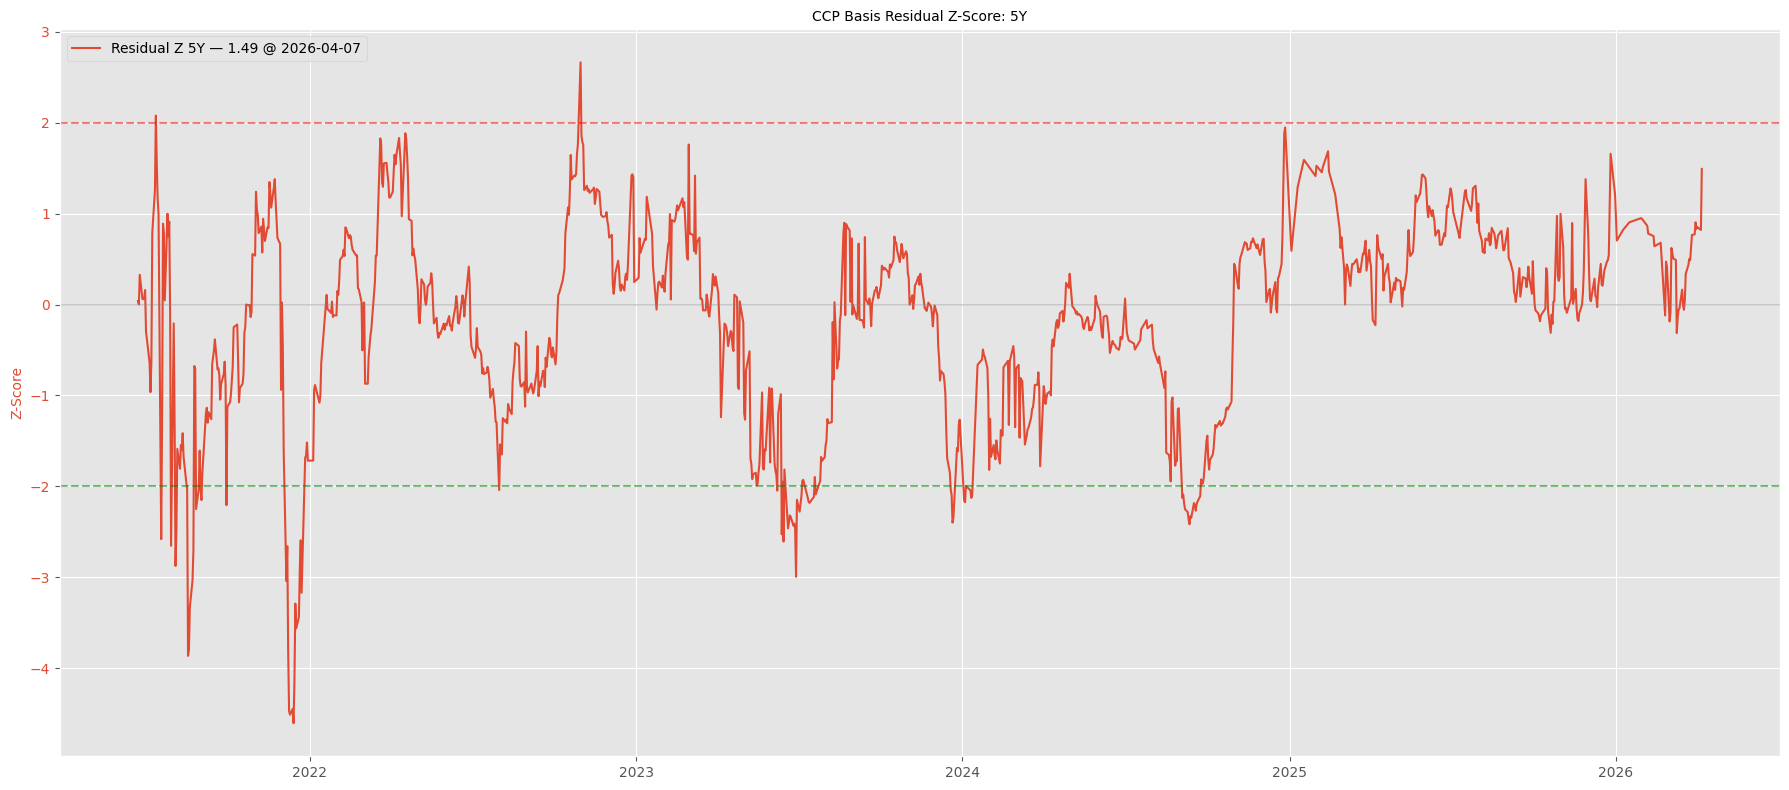

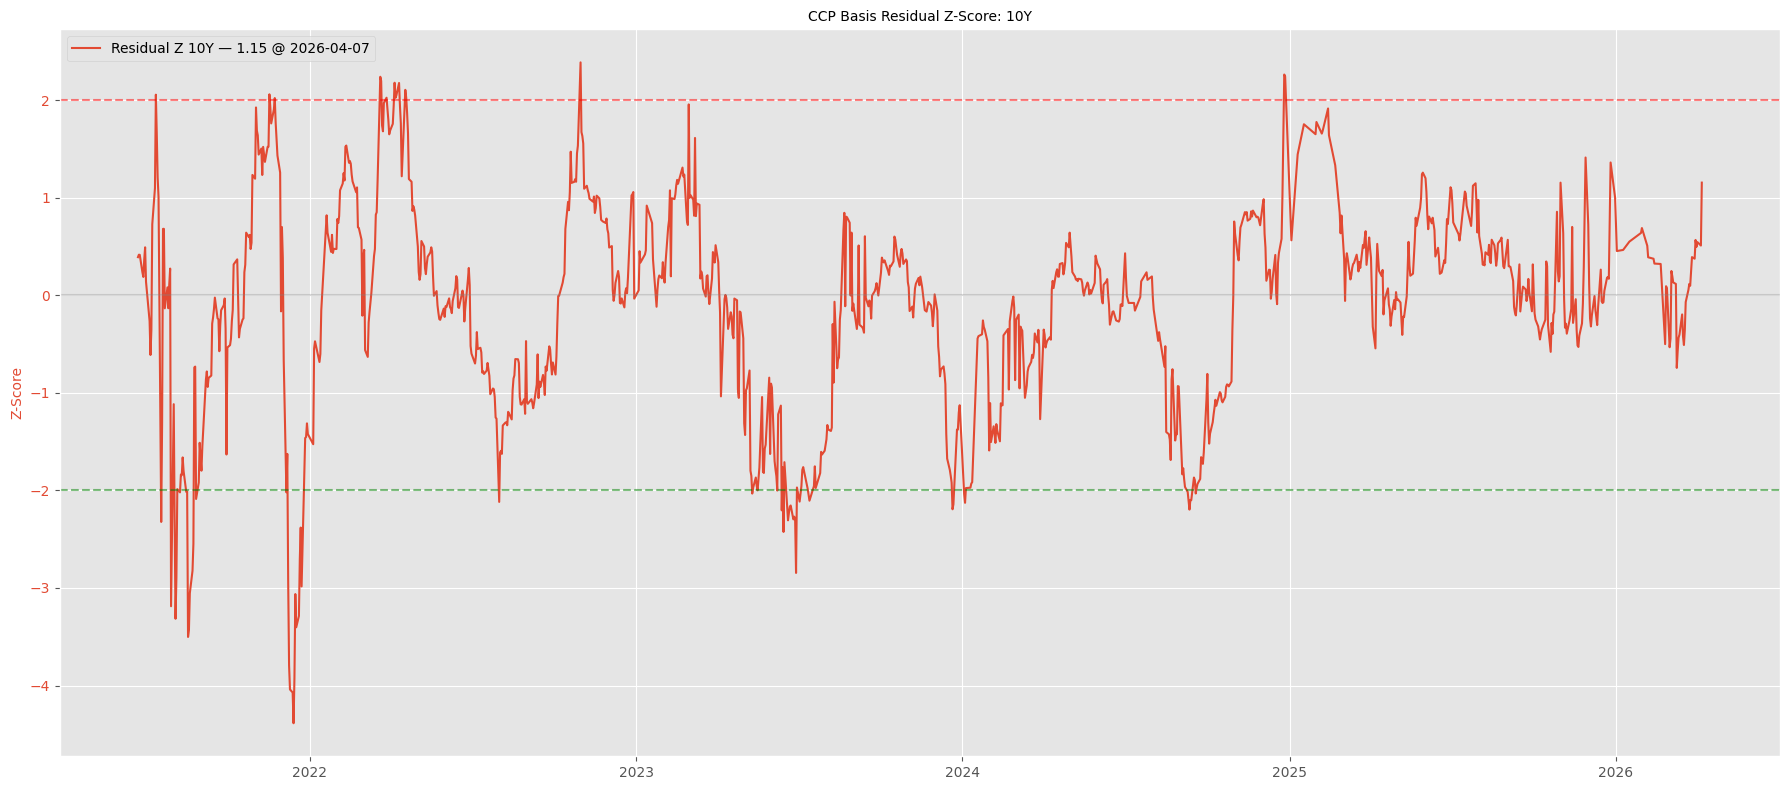

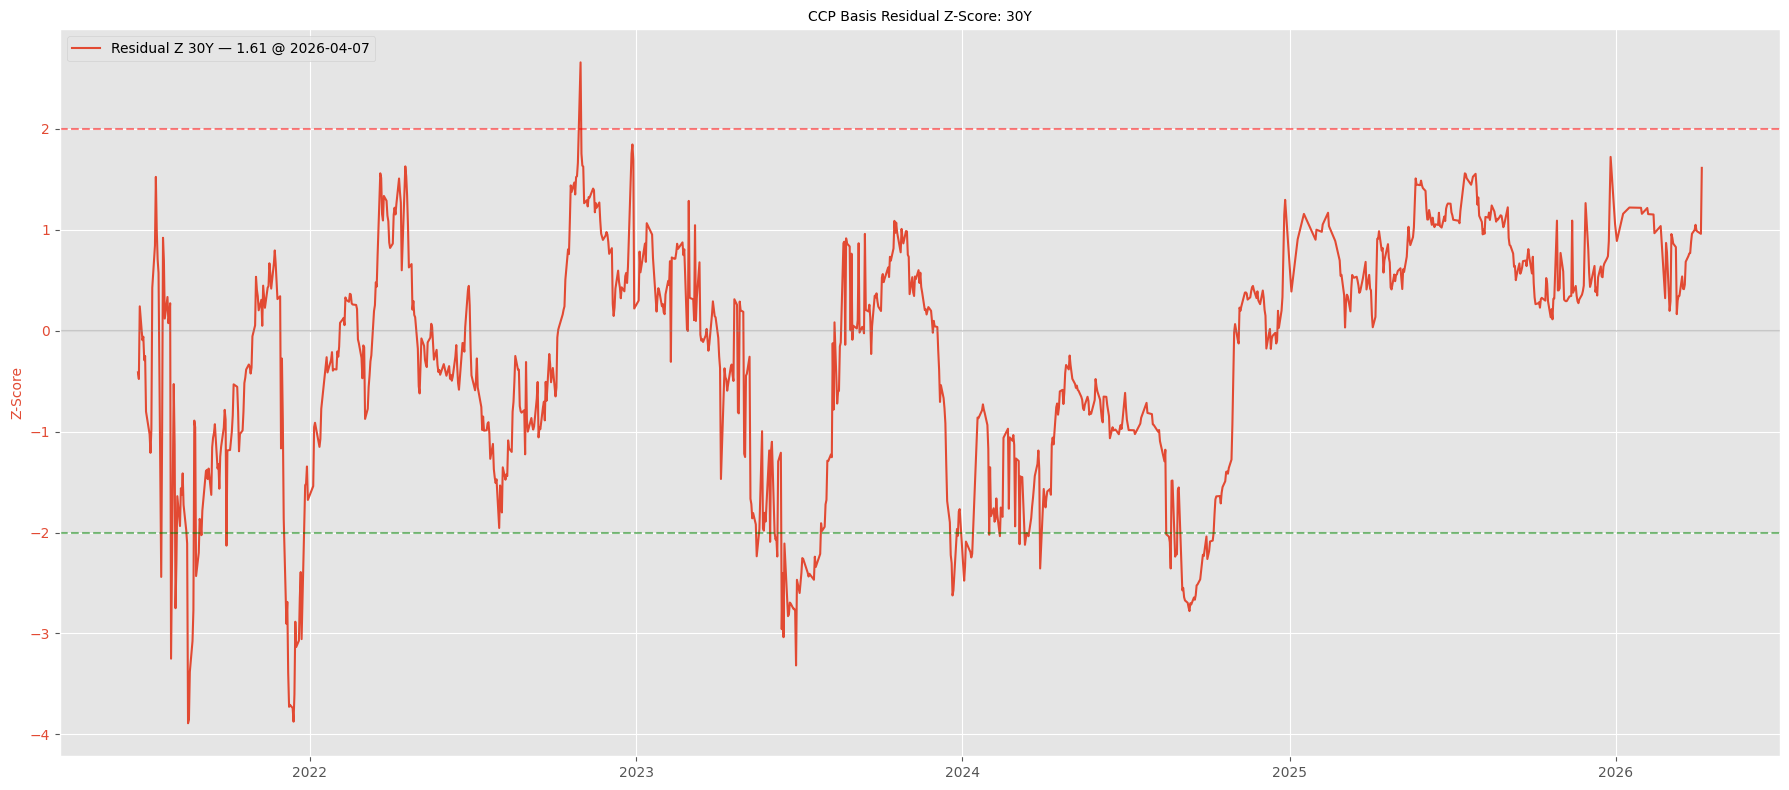

In [70]:
for tenor, result in results.items():
    model.plot_residual_zscore(result)
    plt.show()

## 6. Factor Attribution (30Y)

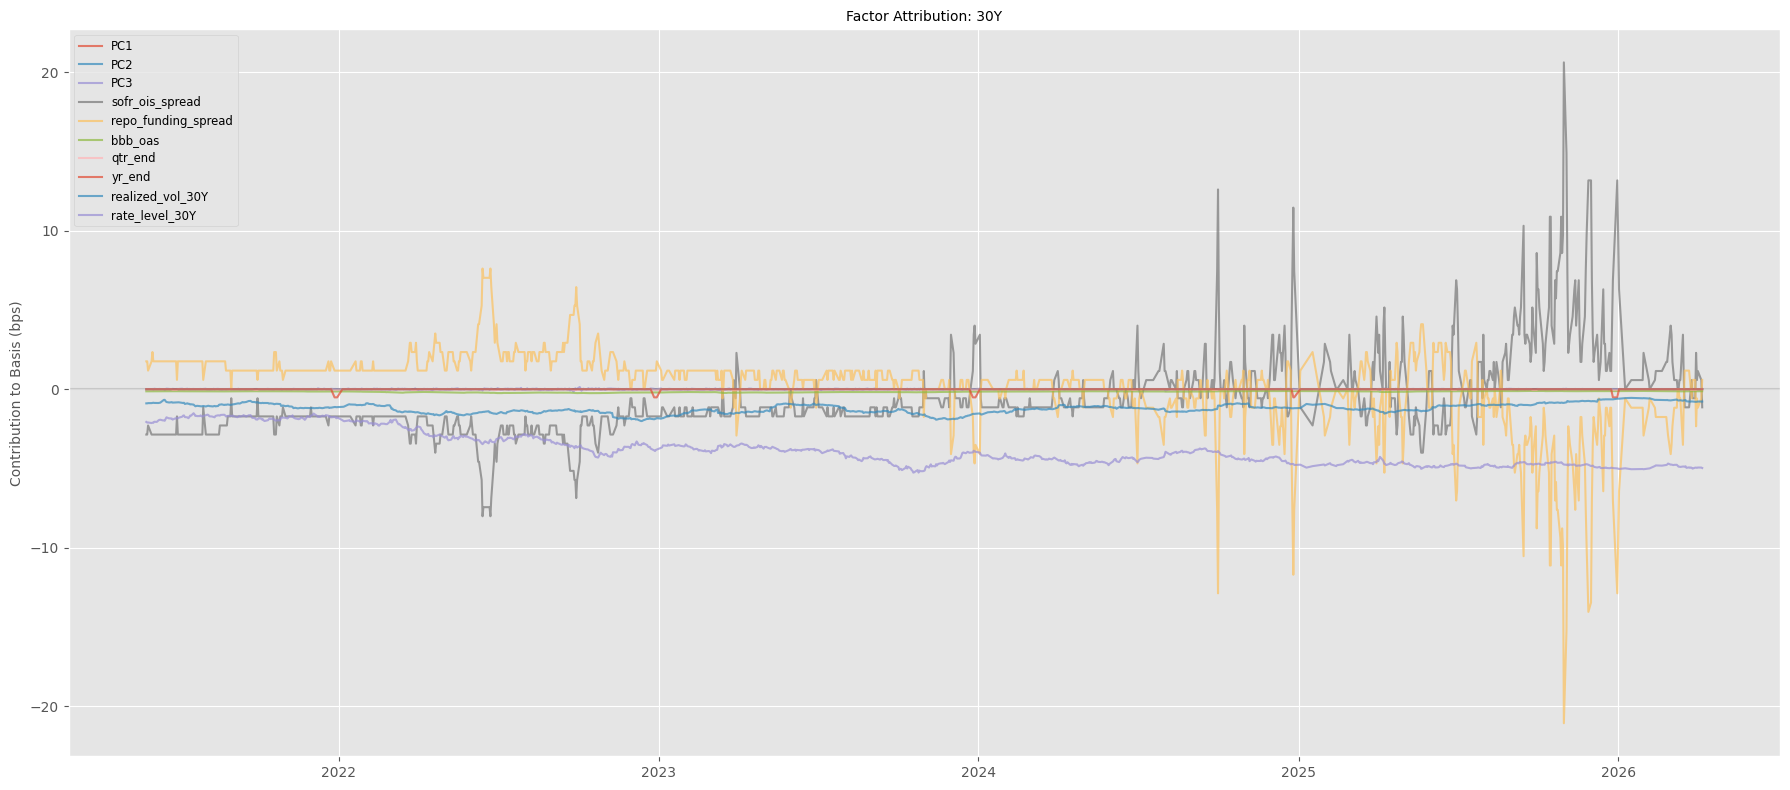

In [71]:
if "30Y" in results:
    model.plot_factor_attribution(results["30Y"])
    plt.show()

## 7. Regression Coefficients Comparison

In [72]:
coeff_df = model.coeff_table()
display(coeff_df.round(4))

,2Y,5Y,10Y,30Y
PC1,-7.9016,-5.8284,-10.3430,-1.5220
PC2,7.1680,2.7585,12.1909,-6.1226
PC3,-99.4161,-124.0146,-102.2128,-228.6897
bbb_oas,0.1175,0.0849,0.2099,-0.1201
const,4.5645,4.9289,4.1578,6.0353
qtr_end,0.0177,0.0029,0.0254,-0.0388
rate_level_10Y,NaN,NaN,-86.3127,NaN
rate_level_2Y,-92.2719,NaN,NaN,NaN
rate_level_30Y,NaN,NaN,NaN,-120.1362
rate_level_5Y,NaN,-98.5876,NaN,NaN


In [73]:
# Regression details for each tenor
for tenor, result in results.items():
    print(f"\n{'='*60}")
    print(f"  {tenor} Regression Summary")
    print(f"{'='*60}")
    print(result.regression_result.summary())


  2Y Regression Summary
                            OLS Regression Results                            
Dep. Variable:               basis_2Y   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     257.6
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          1.62e-279
Time:                        15:29:23   Log-Likelihood:                -954.74
No. Observations:                1107   AIC:                             1931.
Df Residuals:                    1096   BIC:                             1987.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const    

## 8. Basis Term Structure: Actual vs Fair Value

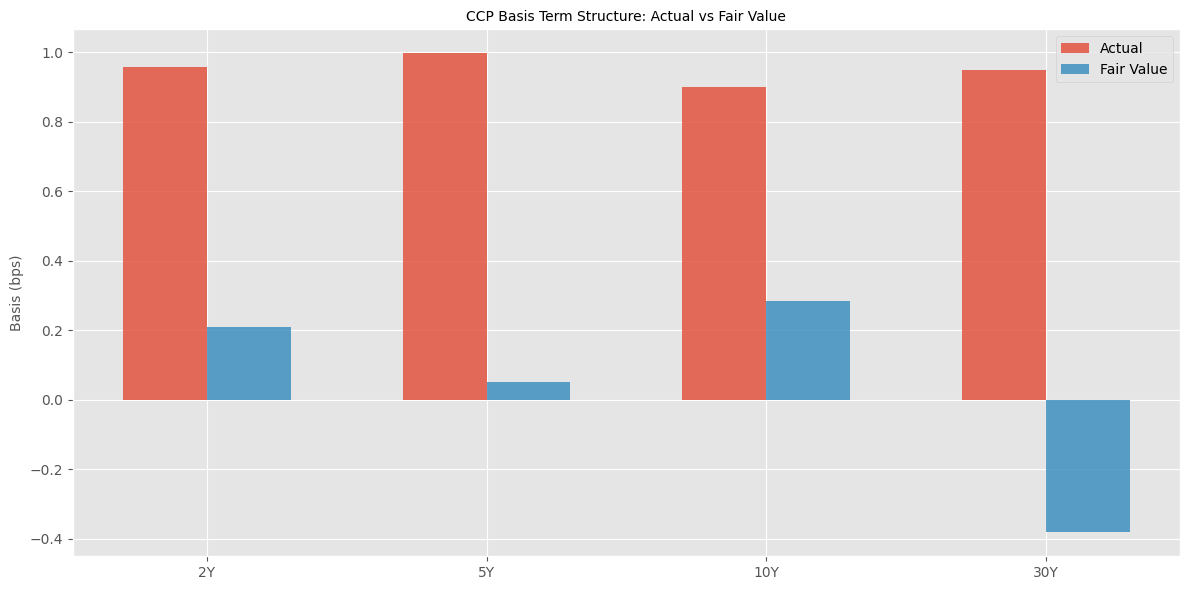

In [74]:
model.plot_basis_term_structure()
plt.show()

## 9. OU Mean Reversion Analysis


2Y: OU half-life = 0.0 days


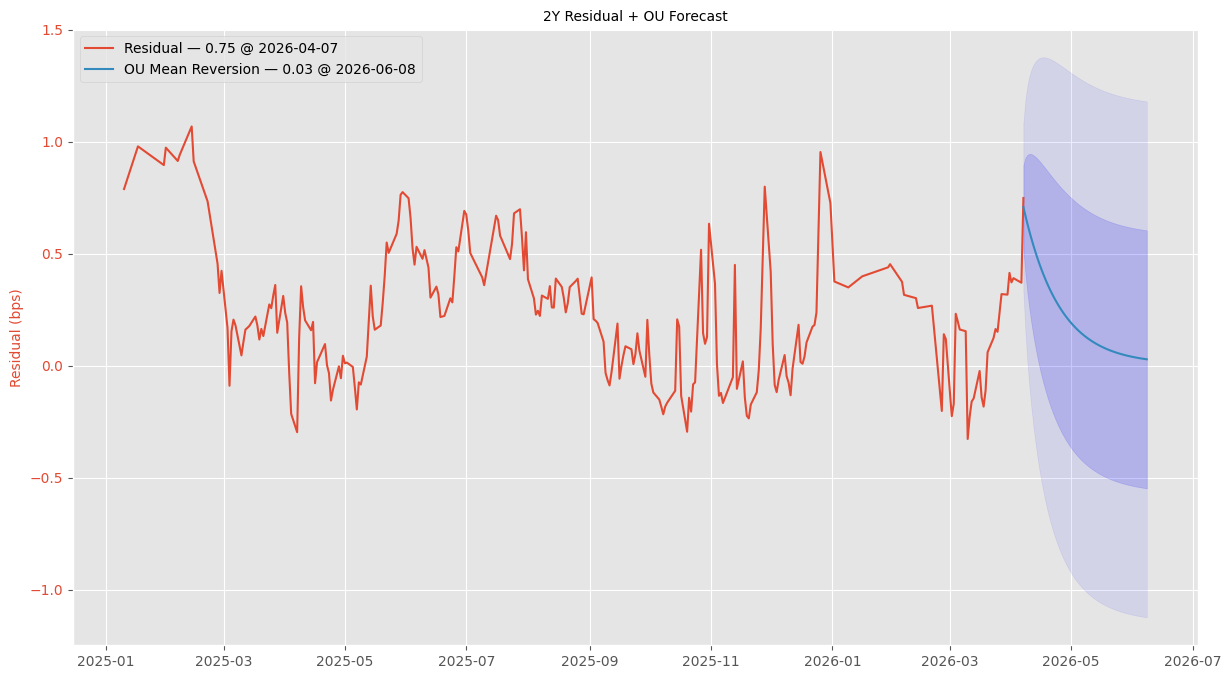


5Y: OU half-life = 0.0 days


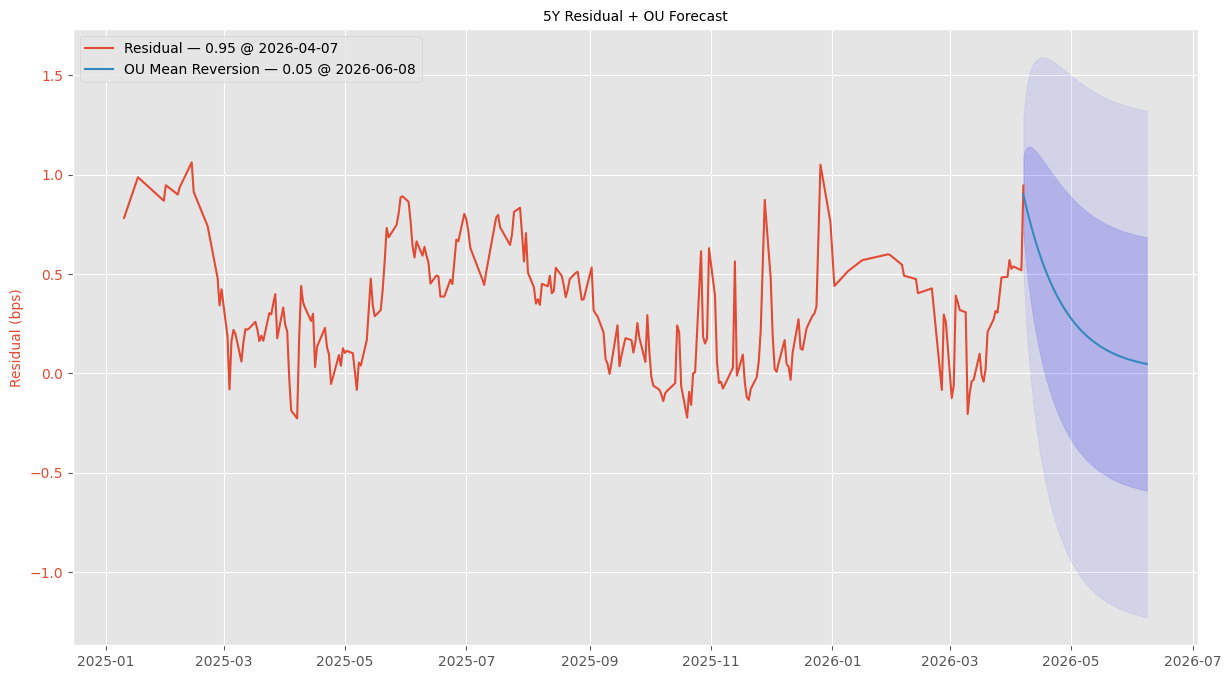


10Y: OU half-life = 0.0 days


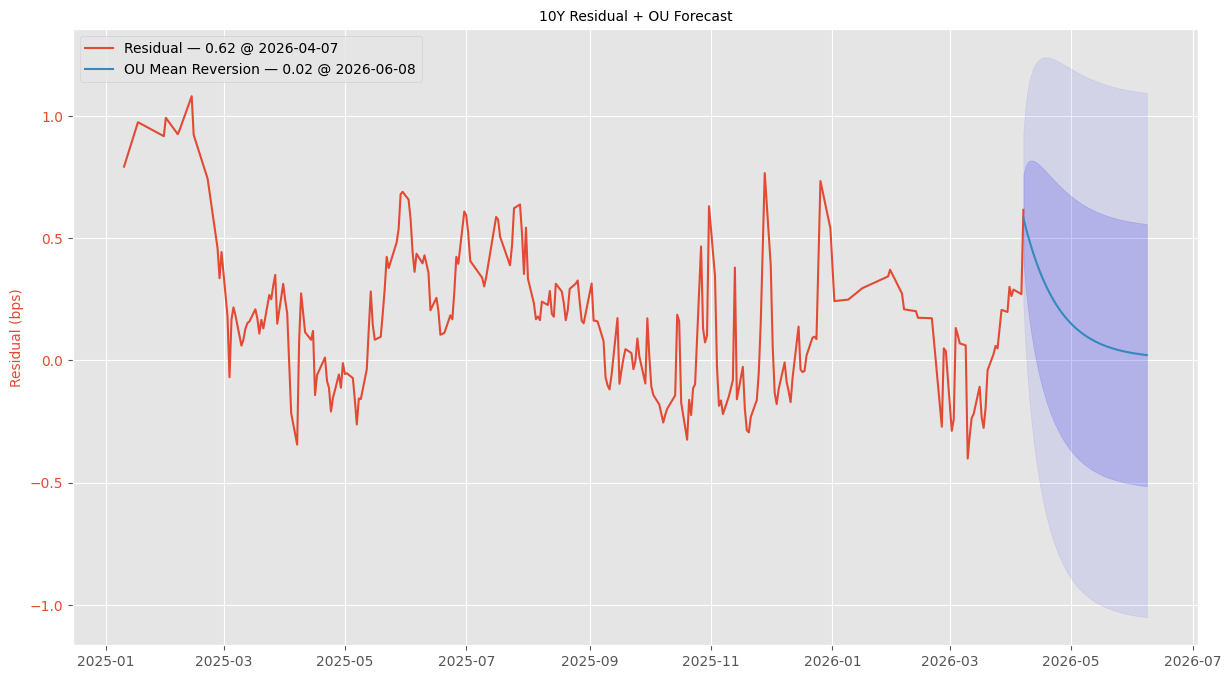


30Y: OU half-life = 0.0 days


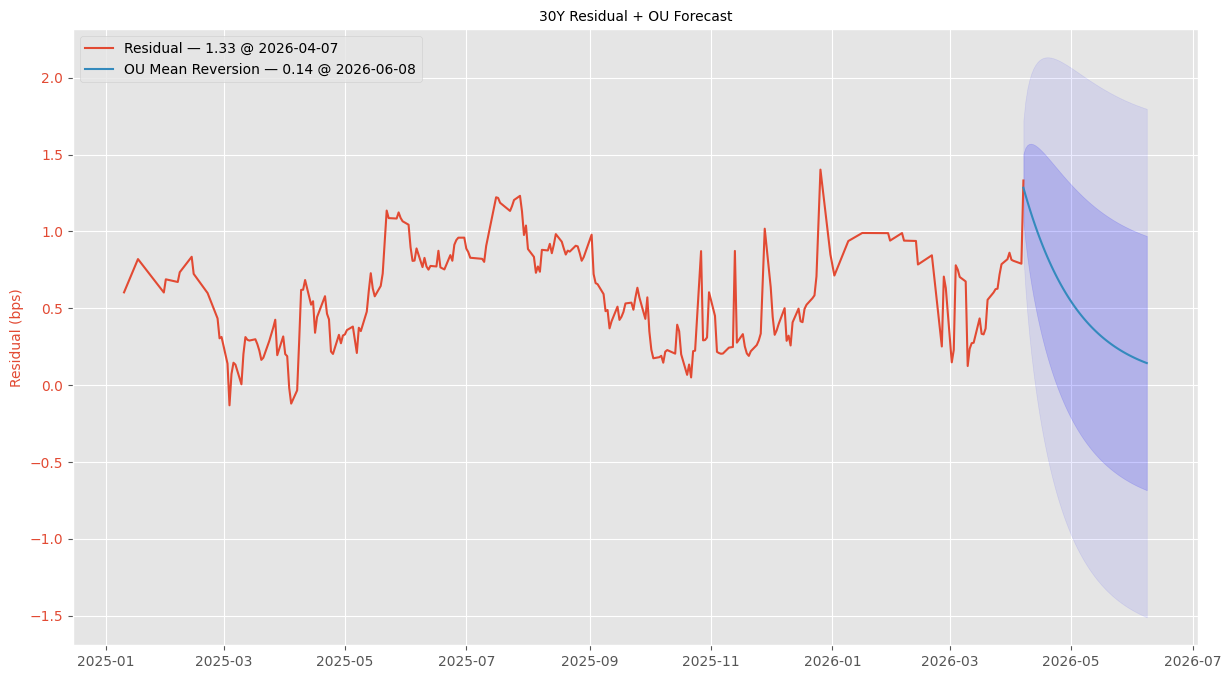

In [75]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

for tenor, result in results.items():
    if result.ou_forecast is not None:
        print(f"\n{tenor}: OU half-life = {result.first_passage_time:.1f} days")
        
        plot, fig, ax, ax2, legend = make_secondary_axis_plot(
            ylabel_left="Residual (bps)",
            title=f"{tenor} Residual + OU Forecast",
        )
        
        # Last 252 days of residual + forecast
        plot(result.residual_ts.iloc[-252:], label="Residual")
        plot(result.ou_forecast["mean_reversion"], label="OU Mean Reversion")
        
        ax.fill_between(
            result.ou_forecast.index,
            result.ou_forecast["+1_sigma"],
            result.ou_forecast["-1_sigma"],
            alpha=0.15, color="blue", label="\u00b11\u03c3"
        )
        ax.fill_between(
            result.ou_forecast.index,
            result.ou_forecast["+2_sigma"],
            result.ou_forecast["-2_sigma"],
            alpha=0.08, color="blue", label="\u00b12\u03c3"
        )
        
        legend(show_date=True, loc="upper left")
        plt.show()

## 10. Factor Correlation Matrix

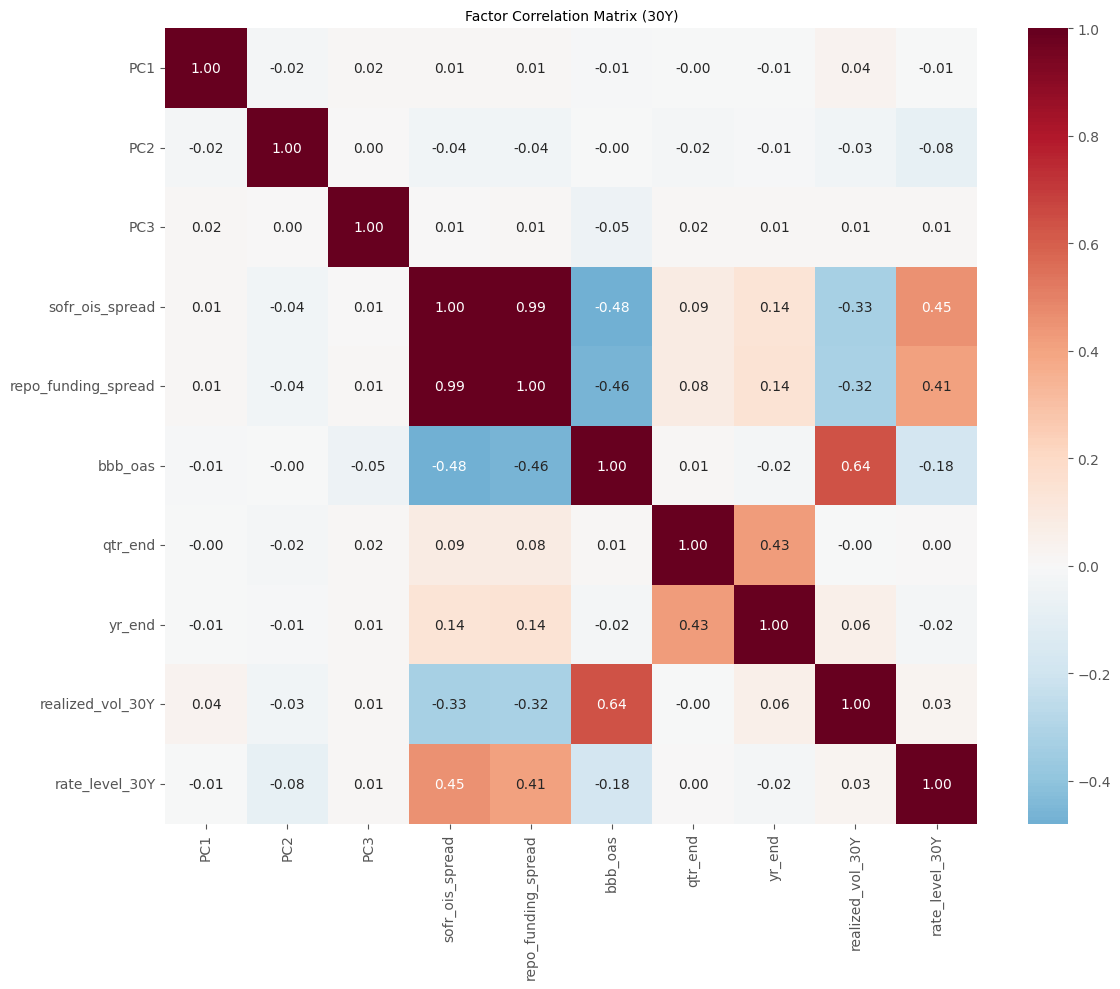

In [76]:
import seaborn as sns

if "30Y" in results:
    corr = results["30Y"].factor_df.corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
    ax.set_title("Factor Correlation Matrix (30Y)")
    plt.tight_layout()
    plt.show()